Importing Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq, ifft


Loading Dataset

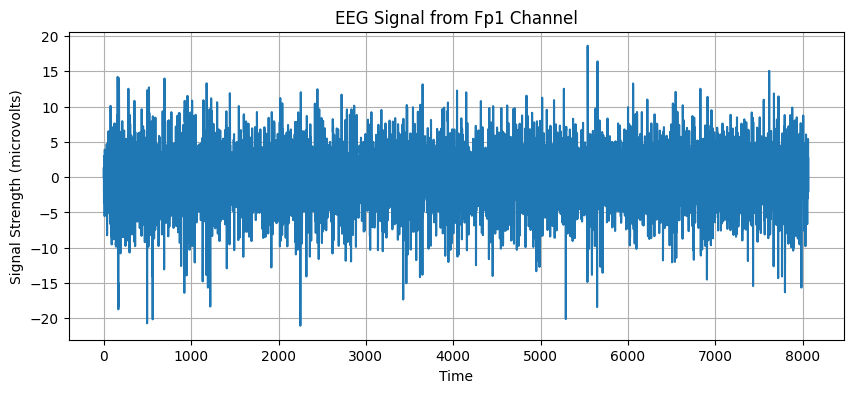

In [5]:
#Loading the dataset
df = pd.read_csv("features_raw.csv") 

#Choosing one channel out of 32 channels (Fp1)
signal = df["Fp1"]

# Plotting the signal from the Fp1 channel
plt.figure(figsize=(10, 4))
plt.plot(signal)
plt.title("EEG Signal from Fp1 Channel")
plt.xlabel("Time")
plt.ylabel("Signal Strength (microvolts)")
plt.grid(True)
plt.show()

In [6]:
fs = 128 
N = 1024 #first 1024 samples
eeg_signal = signal[:N]
t = np.arange(N) / fs

DFT

In [7]:
# Computing the FFT
yf = fft(eeg_signal)
xf = fftfreq(N, 1/fs)  # Frequency values

Plotting the EFG Spectrum

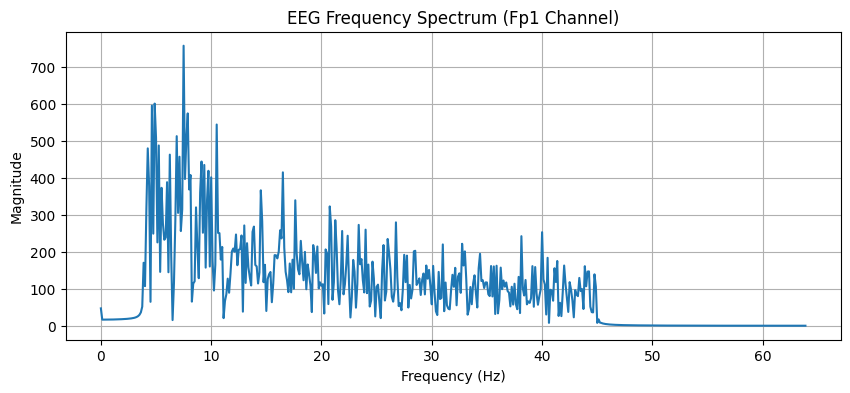

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(xf[:N//2], np.abs(yf[:N//2]))  # Plot positive frequencies only
plt.title("EEG Frequency Spectrum (Fp1 Channel)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

Frequency of Alpha and Beta frequencies


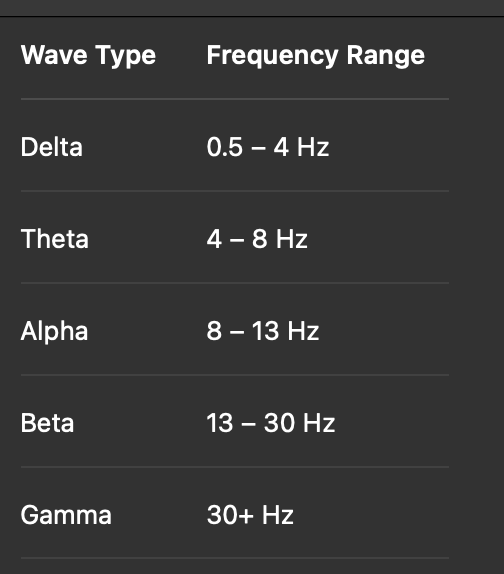

In [9]:
yf_filtered = yf.copy()

# Zero out frequencies not in 8–30 Hz range (alpha + beta)
for i, freq in enumerate(xf):
    if not (8 <= abs(freq) <= 30):
        yf_filtered[i] = 0

Reconstruction by inverse dft and Plotting the signal

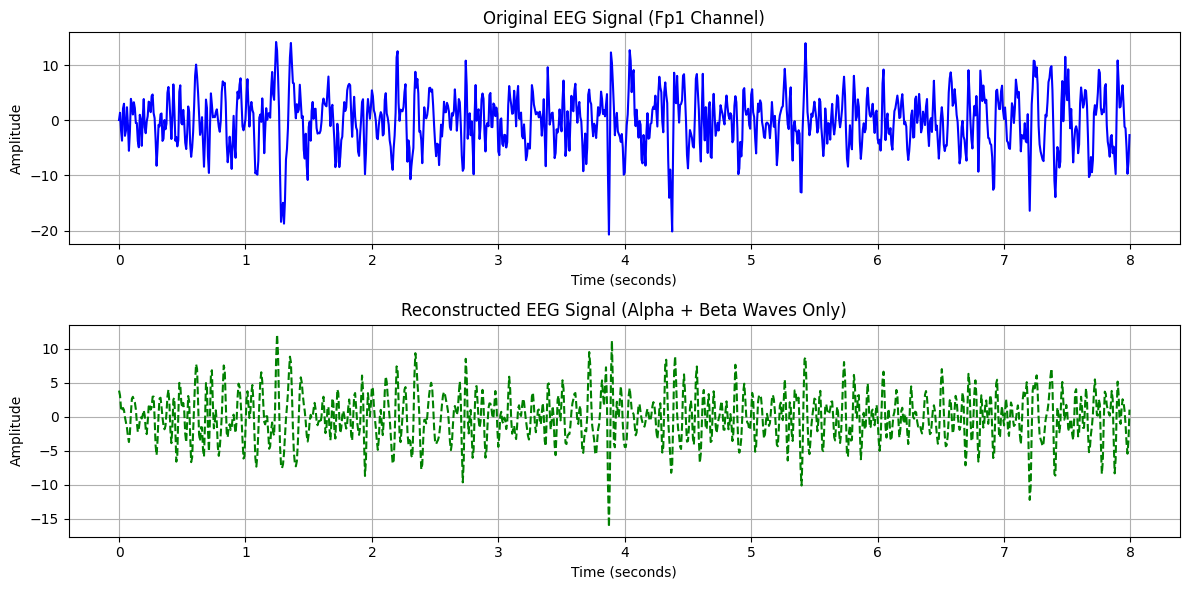

In [11]:
reconstructed_signal = ifft(yf_filtered)

# Plot original and reconstructed signal
plt.figure(figsize=(12, 6))

# Top subplot: Original EEG signal
plt.subplot(2, 1, 1)
plt.plot(t, eeg_signal, color='blue')
plt.title("Original EEG Signal (Fp1 Channel)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

# Bottom subplot: Reconstructed signal (Alpha + Beta only)
plt.subplot(2, 1, 2)
plt.plot(t, reconstructed_signal.real, color='green', linestyle='--')
plt.title("Reconstructed EEG Signal (Alpha + Beta Waves Only)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()